In [1]:
# from pyincore import IncoreClient, DataService, SpaceService, HazardService, Dataset, FragilityService, Mapping, MappingSet, FragilityCurveSet, GeoUtil, Flood, NetworkDataset, NetworkUtil
from pyincore import IncoreClient, Dataset, FragilityService, Mapping, MappingSet, FragilityCurveSet
from pyincore.analyses.buildingdamage import BuildingDamage
# from pyincore.analyses.meandamage import MeanDamage
from pyincore.analyses.montecarlofailureprobability import MonteCarloFailureProbability 

from pyincore_viz.plotutil import PlotUtil as plot
from pyincore_viz.geoutil import GeoUtil as viz

import pandas as pd
import geopandas as gpd
import numpy as np
from scipy.stats import norm, lognorm
import os
import json
import rasterio
import networkx as nx
import contextily as cx
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from rasterio.features import geometry_mask
from shapely.geometry import Point, LineString, box
# from shapely.ops import nearest_points

INFO - utils.py:_init_num_threads() - Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO - utils.py:_init_num_threads() - NumExpr defaulting to 8 threads.


In [2]:
from utility_functions import *

In [3]:
client = IncoreClient()
# data_services = DataService(client)
# space_services = SpaceService(client)
# fragility_services = FragilityService(client)
# hazardsvc = HazardService(client)

Connection successful to IN-CORE services. pyIncore version detected: 1.21.0


## Input Building Data

In [5]:
buildings_local = Dataset.from_file("input_data/sample_buildings.shp", data_type="ergo:buildingInventoryVer4")
buildings_df = buildings_local.get_dataframe_from_shapefile().set_index('uid')
buildings_df.head(3)

,Building_n,Latitude,Longitude,Base_eleva,Barrier_ht,Floors,Height,Occupancy,From_Node,geometry
uid,,,,,,,,,,
1,House1,38.980200,-76.485999,0,0,2,30,RES3,6,POINT (-76.486 38.98)
2,House2,38.979932,-76.485676,0,0,2,30,RES3,6,POINT (-76.486 38.98)
3,House3,38.979717,-76.485350,0,0,2,30,RES3,6,POINT (-76.485 38.98)


In [6]:
# ax = buildings_df.plot(figsize=(20, 10), color = 'Red', marker = 's', markersize=100)
# cx.add_basemap(ax, crs=buildings_df.crs)

## Input Power Network

In [8]:
# Regional Power Grid Nodes and Links
epf_dataset = Dataset.from_file("input_data/epf_nodes_updated.shp", data_type="ergo:nodeInventoryVer1")
epf_gdf = epf_dataset.get_dataframe_from_shapefile().set_index('uid')
epn_dataset = Dataset.from_file("input_data/epn_links_updated.shp", data_type="ergo:edgeInventoryVer1")
epn_gdf = epn_dataset.get_dataframe_from_shapefile()

# Local Power Network Connecting Distribution Substations to Buildings
edges_bldg_subs_dataset = Dataset.from_file("input_data/subs_to_bldgs_edges.shp", data_type="ergo:edgeInventoryVer1")
edges_bldg_subs_df = edges_bldg_subs_dataset.get_dataframe_from_shapefile()

In [9]:
edges_bldg_subs_df

,inode_subs,jnode_buil,linetype,geometry
0,6,1,Transmission Line,"LINESTRING (-76.491 38.991, -76.486 38.98)"
1,6,2,Transmission Line,"LINESTRING (-76.491 38.991, -76.486 38.98)"
2,6,3,Transmission Line,"LINESTRING (-76.491 38.991, -76.485 38.98)"
3,6,4,Transmission Line,"LINESTRING (-76.491 38.991, -76.485 38.979)"
4,6,5,Transmission Line,"LINESTRING (-76.491 38.991, -76.485 38.979)"
5,6,6,Transmission Line,"LINESTRING (-76.491 38.991, -76.484 38.979)"
6,6,7,Transmission Line,"LINESTRING (-76.491 38.991, -76.485 38.98)"
7,6,8,Transmission Line,"LINESTRING (-76.491 38.991, -76.483 38.981)"
8,6,9,Transmission Line,"LINESTRING (-76.491 38.991, -76.487 38.983)"
9,6,10,Transmission Line,"LINESTRING (-76.491 38.991, -76.487 38.984)"


## Input Transportation Network Data

In [11]:
# get link dataset from data service
node_dataset = Dataset.from_file("input_data/nodes.shp", data_type="ergo:nodeInventoryVer1")
nodes_df = node_dataset.get_dataframe_from_shapefile()

# get link dataset from data service
edge_dataset = Dataset.from_file("input_data/edges.shp", data_type="ergo:edgeInventoryVer1")
edge_df = edge_dataset.get_dataframe_from_shapefile()

In [12]:
nodes_df = nodes_df.rename(columns = {'osmid': 'nodenwid'})
edge_df = edge_df.rename(columns = {'osmid': 'linknwid',
                           'u': 'fromnode',
                           'v': 'tonode'})

g = create_networkx_graph(nodes_df, edge_df)

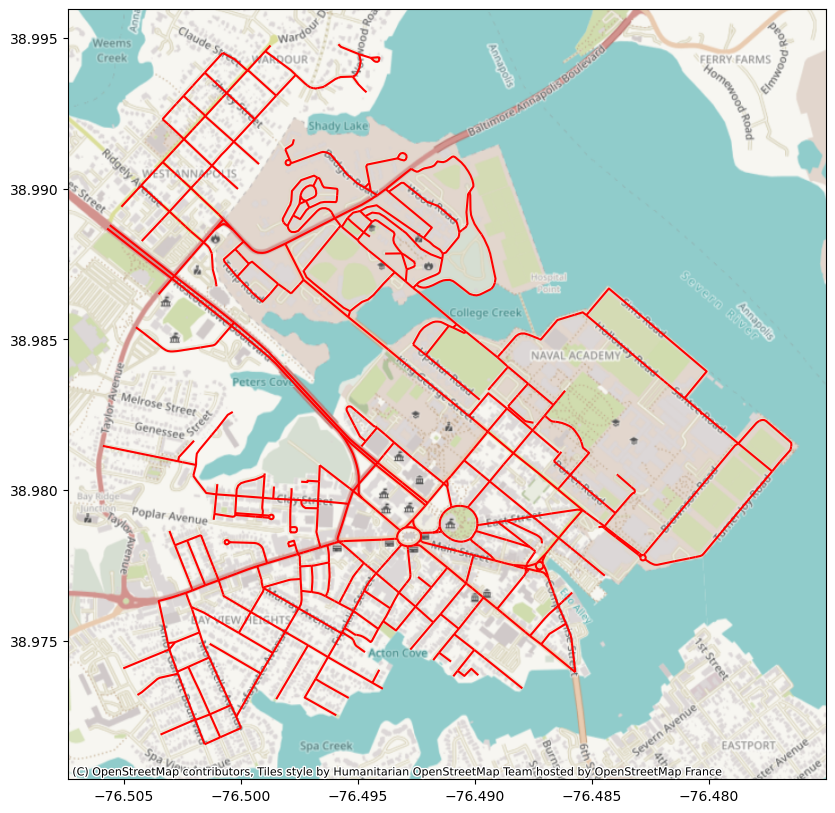

In [13]:
### Plot Transportation Network shapefiles
# ax = nodes_df.plot(figsize=(20, 10), column='inundationDepth', categorical=True, markersize=20, legend=True, cmap = 'Blues')
ax = edge_df.plot(figsize=(20, 10), color='r')
cx.add_basemap(ax, crs=nodes_df.crs)

## Import Elevation Data

The elevation map is saved in the form of a raster file that can be read into the Notebook and the values of the raster can be attached to the individual structural locations based on proximity.

In [16]:
raster_path = 'input_data/USGS_1_n39w077_20220713.tif'

buildings_df = attach_flood_hazard(buildings_df, 
                                   raster_path, 
                                   raster_value = 'elevation')

epf_gdf = attach_flood_hazard(epf_gdf, 
                                     raster_path, 
                                     raster_value = 'elevation')

## Input Hazard Data

The hazard map is saved in the form of a raster file that can be read into the Notebook and the values of the raster can be attached to the individual structural locations based on proximity.

In [19]:
raster_path = 'input_data/cat4_high_raster.tif'

buildings_df = attach_flood_hazard(buildings_df, raster_path, raster_value = 'water_depth')
buildings_df['inundationDepth'] = buildings_df['water_depth'] - buildings_df['elevation']
buildings_df['inundationDepth'] = buildings_df['inundationDepth'].apply(lambda x: max(x, 0))
buildings_df.head(3)

,Building_n,Latitude,Longitude,Base_eleva,Barrier_ht,Floors,Height,Occupancy,From_Node,geometry,elevation,water_depth,inundationDepth
uid,,,,,,,,,,,,,
1,House1,38.980200,-76.485999,0,0,2,30,RES3,6,POINT (-76.486 38.98),2.569192,2.827191,0.257999
2,House2,38.979932,-76.485676,0,0,2,30,RES3,6,POINT (-76.486 38.98),1.930152,2.827191,0.897038
3,House3,38.979717,-76.485350,0,0,2,30,RES3,6,POINT (-76.485 38.98),1.807689,2.827191,1.019502


In [20]:
# # viz.plot_gdf_map(buildings_df, column='inundationDepth')
# ### Plot EPN shapefiles
# ax = buildings_df.plot(figsize=(20, 10), column='inundationDepth', categorical=True, markersize=150, legend=True, cmap = 'Blues')
# cx.add_basemap(ax, crs=nodes_df.crs)

In [21]:
epf_gdf = attach_flood_hazard(epf_gdf, raster_path, raster_value = 'water_depth')
epf_gdf['inundationDepth'] = epf_gdf['water_depth'] - epf_gdf['elevation']
epf_gdf['inundationDepth'] = epf_gdf['inundationDepth'].apply(lambda x: max(x, 0))
epf_gdf

,Name,Latitude,Longitude,Type,From_Node,facility_t,geometry,elevation,water_depth,inundationDepth
uid,,,,,,,,,,
1,Calvert Cliffs Power Plant,38.431945,-76.441607,Nuclear Power Plant,None,Power Plant,POINT (-76.442 38.432),18.118330,7.731699,0.000000
2,Herbert A Wagner Generating Station,39.177846,-76.525819,Coal and Natural Gas Plant,None,Power Plant,POINT (-76.526 39.178),1.624268,7.312860,5.688592
3,BGE Bestgate Substation,38.992267,-76.547425,Transmission,"1, 2",Transmission Substation,POINT (-76.547 38.992),26.499935,0.000000,0.000000
4,Arnold BGE Substation,39.037100,-76.481000,Distribution,2,Distribution Substation,POINT (-76.481 39.037),0.000000,0.000000,0.000000
5,BGE Greenburry Point Substation,38.996257,-76.473759,Distribution,2,Distribution Substation,POINT (-76.474 38.996),23.132006,0.000000,0.000000
6,BGE US Navy Severn Substation,38.990940,-76.491020,Distribution,3,Distribution Substation,POINT (-76.491 38.991),1.356403,14.029014,12.672611
7,BGE Cedar Park Substation,38.979300,-76.501500,Distribution,3,Distribution Substation,POINT (-76.501 38.979),9.689898,0.000000,0.000000
8,BGE Tyer Avenue Substation,38.960900,-76.491900,Distribution,1,Distribution Substation,POINT (-76.492 38.961),4.651736,3.160006,0.000000


In [22]:
nodes_df = attach_flood_hazard(nodes_df, raster_path)
nodes_df.head(3)

# edge_df = attach_flood_hazard(edge_df, raster_path)
# edge_df

,nodenwid,y,x,highway,ref,geometry,inundationDepth
0,7185334298,38.985016,-76.487252,None,None,POINT (-76.487 38.985),14.029014
1,102629495,38.992313,-76.499406,None,None,POINT (-76.499 38.992),3.067575
2,102629499,38.990768,-76.501229,None,None,POINT (-76.501 38.991),0.000000


## Fragility Model Definition

### Buildings

In [25]:
fragility_curve_set1, fragility_curve_set2, local_building_mapping_set = get_building_fragility()

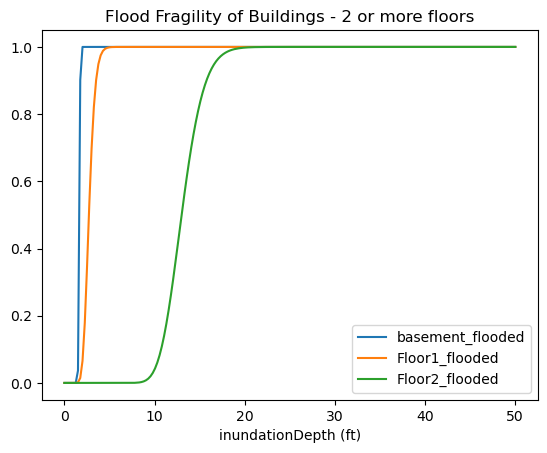

In [26]:
plt = plot.get_fragility_plot(fragility_curve_set1, start=0, end=50)

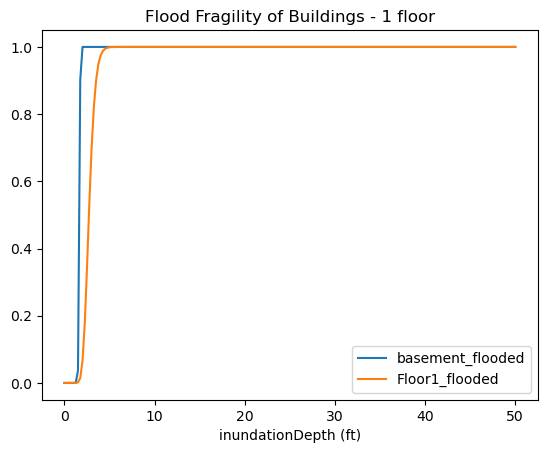

In [27]:
plt = plot.get_fragility_plot(fragility_curve_set2, start=0, end=50)

### Substations

In [29]:
fragility_curve_set_substations = get_substation_fragility()

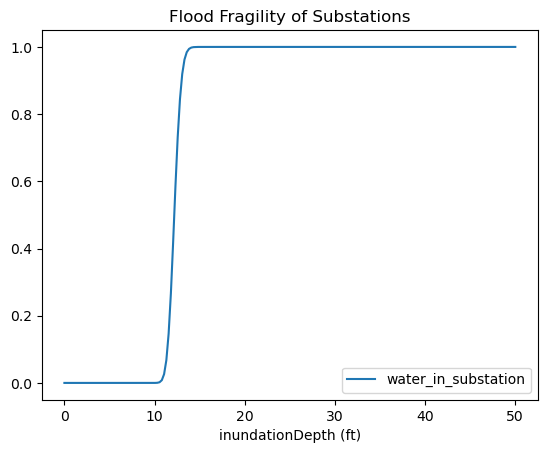

In [30]:
plt = plot.get_fragility_plot(fragility_curve_set_substations, start=0, end=50)

### Roads

In [32]:
fragility_curve_set_roads = get_road_fragility()

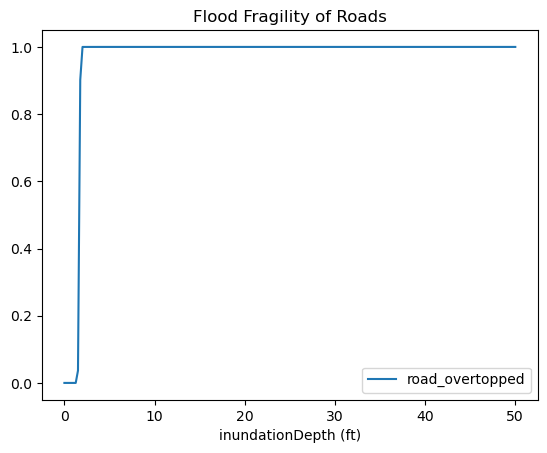

In [33]:
plt = plot.get_fragility_plot(fragility_curve_set_roads, start=0, end=50)

## Perform Damage Analysis

### Buildings

In [36]:
buildings_df = run_building_damage_analysis(buildings_df, local_building_mapping_set)
buildings_df.head(3)

,Building_n,Latitude,Longitude,Base_eleva,Barrier_ht,Floors,Height,Occupancy,From_Node,geometry,elevation,water_depth,inundationDepth,LS_0,LS_1,LS_2,DS_0,DS_1,DS_2,DS_3
uid,,,,,,,,,,,,,,,,,,,,
1,House1,38.980200,-76.485999,0,0,2,30,RES3,6,POINT (-76.486 38.98),2.569192,2.827191,0.257999,0.0,0.000000e+00,0.0,1.0,0.000000e+00,0.000000e+00,0.0
2,House2,38.979932,-76.485676,0,0,2,30,RES3,6,POINT (-76.486 38.98),1.930152,2.827191,0.897038,0.0,1.480000e-08,0.0,1.0,-1.480000e-08,1.480000e-08,0.0
3,House3,38.979717,-76.485350,0,0,2,30,RES3,6,POINT (-76.485 38.98),1.807689,2.827191,1.019502,0.0,4.709000e-07,0.0,1.0,-4.709000e-07,4.709000e-07,0.0


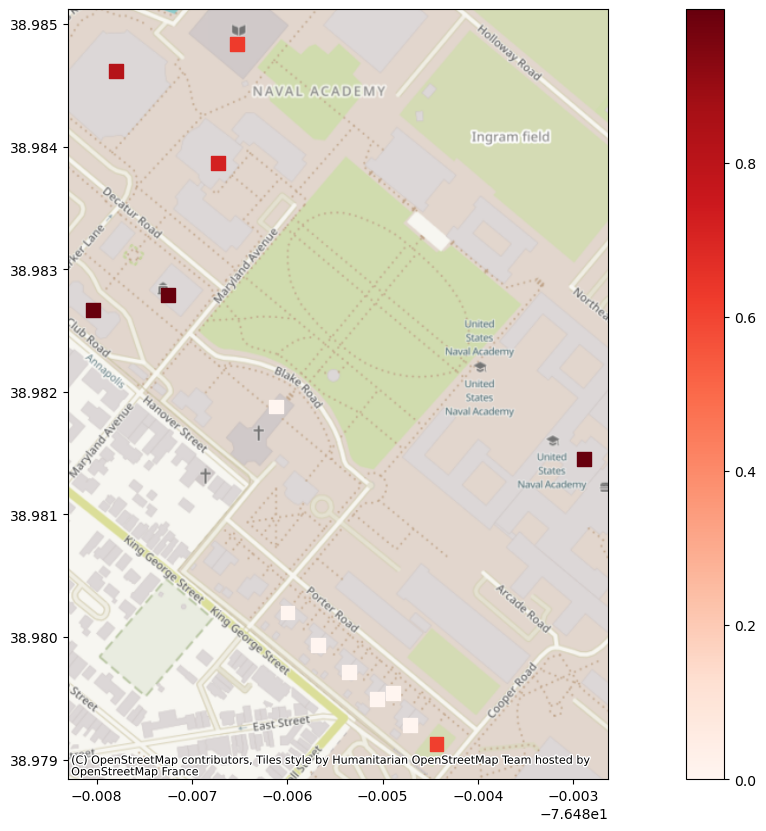

In [37]:
ax = buildings_df.plot(figsize=(20, 10), column='DS_2', legend=True, cmap = 'Reds', marker = 's', markersize=100)
cx.add_basemap(ax, crs=buildings_df.crs)

### Substations

In [39]:
epf_gdf = run_substation_damage_analysis(epf_gdf, fragility_curve_set_substations)

In [40]:
epf_gdf

,Name,Latitude,Longitude,Type,From_Node,facility_t,geometry,elevation,water_depth,inundationDepth,LS_0,DS_0,DS_1
uid,,,,,,,,,,,,,
1,Calvert Cliffs Power Plant,38.431945,-76.441607,Nuclear Power Plant,None,Power Plant,POINT (-76.442 38.432),18.118330,7.731699,0.000000,0.000000,1.000000,0.000000
2,Herbert A Wagner Generating Station,39.177846,-76.525819,Coal and Natural Gas Plant,None,Power Plant,POINT (-76.526 39.178),1.624268,7.312860,5.688592,0.000000,1.000000,0.000000
3,BGE Bestgate Substation,38.992267,-76.547425,Transmission,"1, 2",Transmission Substation,POINT (-76.547 38.992),26.499935,0.000000,0.000000,0.000000,1.000000,0.000000
4,Arnold BGE Substation,39.037100,-76.481000,Distribution,2,Distribution Substation,POINT (-76.481 39.037),0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
5,BGE Greenburry Point Substation,38.996257,-76.473759,Distribution,2,Distribution Substation,POINT (-76.474 38.996),23.132006,0.000000,0.000000,0.000000,1.000000,0.000000
6,BGE US Navy Severn Substation,38.990940,-76.491020,Distribution,3,Distribution Substation,POINT (-76.491 38.991),1.356403,14.029014,12.672611,0.784903,0.215097,0.784903
7,BGE Cedar Park Substation,38.979300,-76.501500,Distribution,3,Distribution Substation,POINT (-76.501 38.979),9.689898,0.000000,0.000000,0.000000,1.000000,0.000000
8,BGE Tyer Avenue Substation,38.960900,-76.491900,Distribution,1,Distribution Substation,POINT (-76.492 38.961),4.651736,3.160006,0.000000,0.000000,1.000000,0.000000


In [41]:
epn_gdf

,fromnode,tonode,linetype,geometry
0,1,3,Transmission Line,"LINESTRING (-76.442 38.432, -76.463 38.544, -7..."
1,2,3,Transmission Line,"LINESTRING (-76.526 39.178, -76.53 39.141, -76..."
2,2,4,Transmission Line,"LINESTRING (-76.526 39.178, -76.517 39.15, -76..."
3,2,5,Transmission Line,"LINESTRING (-76.526 39.178, -76.515 39.142, -7..."
4,3,6,Distribution Line,"LINESTRING (-76.547 38.992, -76.536 38.992, -7..."
5,3,7,Distribution Line,"LINESTRING (-76.547 38.992, -76.538 38.99, -76..."
6,1,8,Transmission Line,"LINESTRING (-76.442 38.432, -76.452 38.538, -7..."


### Buildings Power

In [43]:
buildings_df, epf_gdf = run_buildings_power(epf_gdf, epn_gdf, buildings_df, edges_bldg_subs_df)

In [44]:
# ax = buildings_df.plot(figsize=(20, 10), column='DS_power', legend=True, cmap = 'Reds', marker = 's', markersize=100)
# cx.add_basemap(ax, crs=buildings_df.crs)

### Roads

In [46]:
edge_df = run_road_damage_analysis(edge_df, fragility_curve_set_roads)

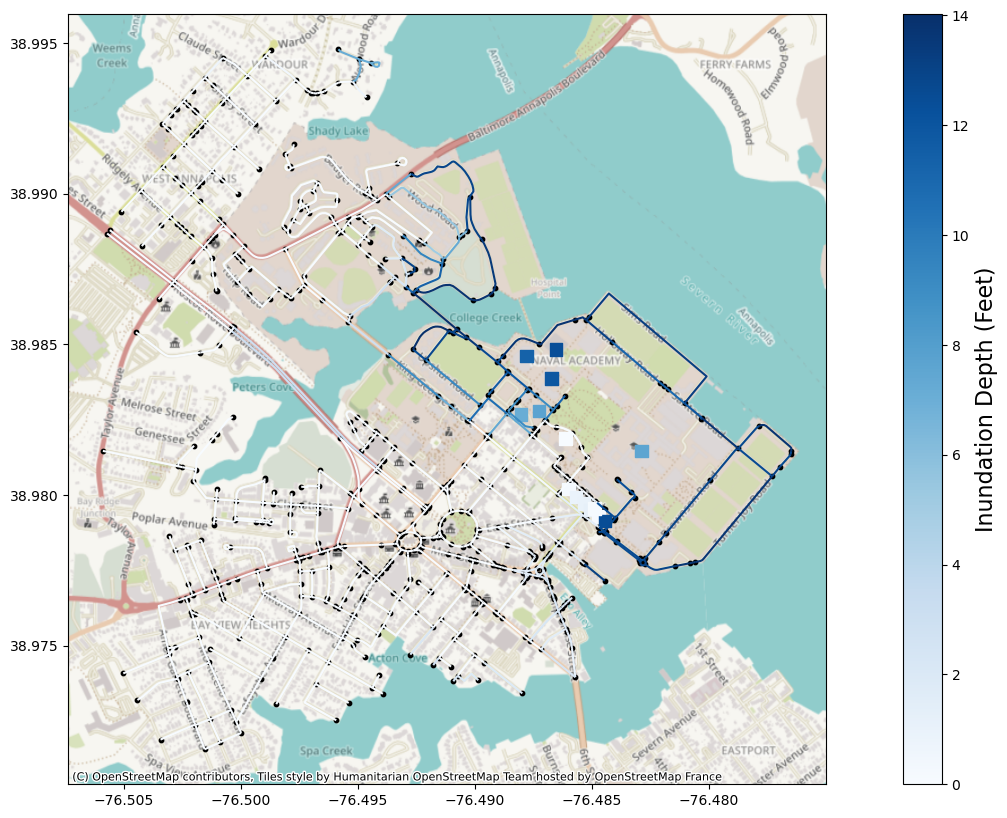

In [47]:
### Plot Transportation Network shapefiles

# Define colormap
cmap = cm.Blues
norm = mcolors.Normalize(vmin=0.0, vmax=edge_df['inundationDepth'].max())

ax = nodes_df.plot(figsize=(20, 10), color = 'k', markersize=10)
edge_plot = edge_df.plot(ax=ax, column='inundationDepth', legend=False, cmap = cmap, norm = norm)
building_plot = buildings_df.plot(ax=ax, column='inundationDepth', marker = 's', markersize=80, legend=False, cmap = cmap, norm = norm)

# Add colorbar manually
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)

# Add label to the colorbar
cbar.set_label("Inundation Depth (Feet)", fontsize=16)
# ax.set_title('Map Showing Probability of Failure for Roads and Probability of 1st Floor Flooding in Buildings', fontsize = 16)

cx.add_basemap(ax, crs=nodes_df.crs)

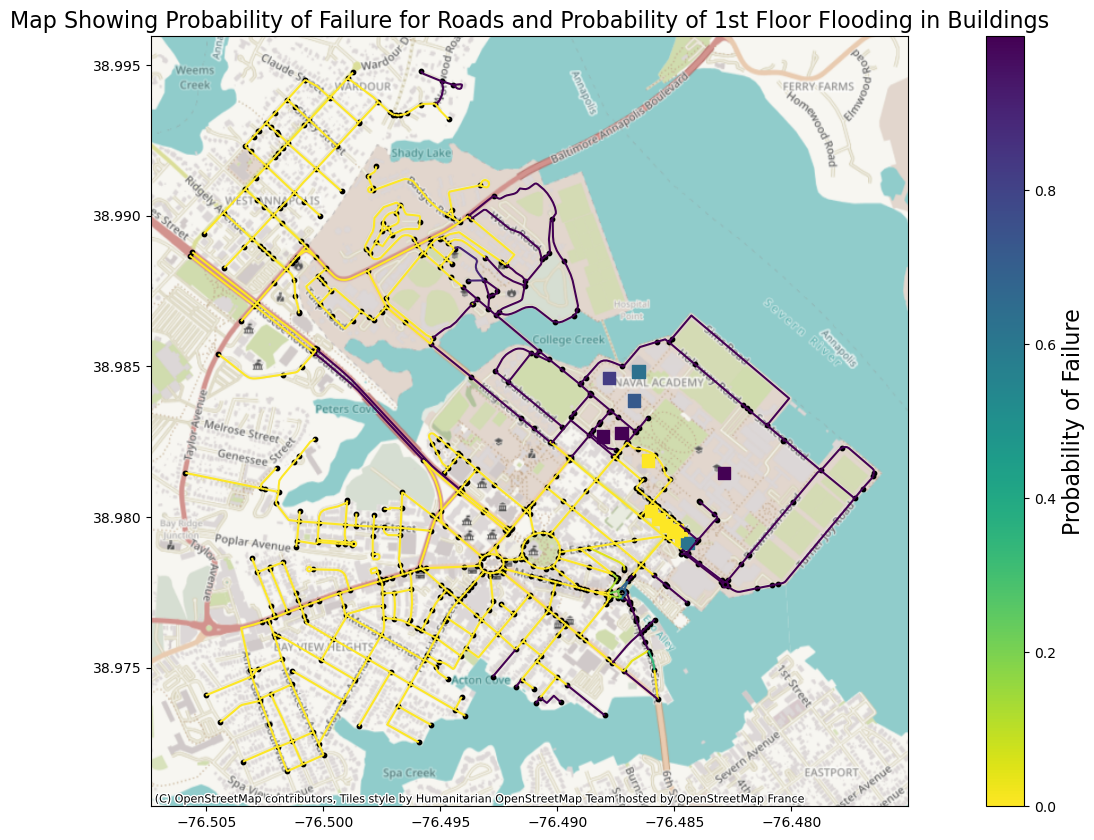

In [48]:
### Plot Transportation Network shapefiles

# Define colormap
cmap = cm.viridis_r
norm = mcolors.Normalize(vmin=0.0, vmax=buildings_df['DS_2'].max())

ax = nodes_df.plot(figsize=(20, 10), color = 'k', markersize=10)
edge_plot = edge_df.plot(ax=ax, column='DS_1', legend=False, cmap = cmap, norm = norm)
building_plot = buildings_df.plot(ax=ax, column='DS_2', marker = 's', markersize=80, legend=False, cmap = cmap, norm = norm)

# Add colorbar manually
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)

# Add label to the colorbar
cbar.set_label("Probability of Failure", fontsize=16)
ax.set_title('Map Showing Probability of Failure for Roads and Probability of 1st Floor Flooding in Buildings', fontsize = 16)

cx.add_basemap(ax, crs=nodes_df.crs)
                

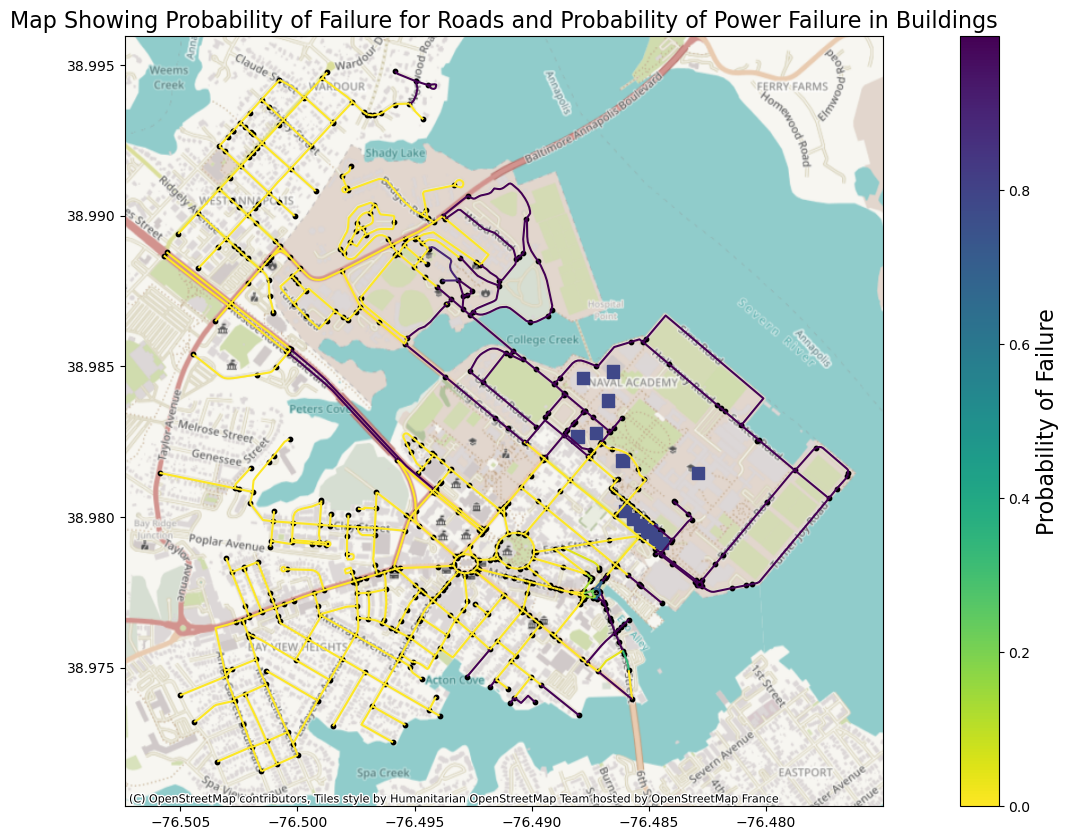

In [49]:
### Plot Transportation Network shapefiles

# Define colormap
cmap = cm.viridis_r
norm = mcolors.Normalize(vmin=0.0, vmax=buildings_df['DS_2'].max())

ax = nodes_df.plot(figsize=(20, 10), color = 'k', markersize=10)
edge_plot = edge_df.plot(ax=ax, column='DS_1', legend=False, cmap = cmap, norm = norm)
building_plot = buildings_df.plot(ax=ax, column='DS_powerfail', marker = 's', markersize=80, legend=False, cmap = cmap, norm = norm)

# Add colorbar manually
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)

# Add label to the colorbar
cbar.set_label("Probability of Failure", fontsize=16)
ax.set_title('Map Showing Probability of Failure for Roads and Probability of Power Failure in Buildings', fontsize = 16)

cx.add_basemap(ax, crs=nodes_df.crs)
                

## Monte Carlo Simulation

In [51]:
num_samples = 100

### Building Failure Simulations

In [53]:
buildings_df_mc = montecarloFailureSim(buildings_df.copy(), 
                                   ["DS_0", "DS_1", "DS_2", "DS_3"],
                                   num_samples)

### Building Power Failure Simulations

In [55]:
buildings_df_mc = montecarloFailureSim(buildings_df.copy(), 
                                   ["DS_nopower", "DS_power"],
                                   num_samples)

### Transportation Failure Simulations

In [57]:
edge_df_mc = montecarloFailureSim(edge_df.copy(), 
                               ["DS_0", "DS_1"],
                               num_samples)

## Network Resilience Metric Computation

In [59]:
# Create Networkx graph object from nodes and edges database
G = create_networkx_graph(nodes_df, edge_df)

In [60]:
### Add nearest network node ID to buildings GeoDataFrame
buildings_df['nearest_node'] = buildings_df.apply(
    lambda row: find_nearest_network_node(row, nodes_df), axis=1
)

building_nodes = np.array(nodes_df.loc[buildings_df['nearest_node'], 'nodenwid'])

# Identify the edge nodes in the network
boundary_nodes = np.array([node for node, degree in G.degree() if degree == 1])
boundary_nodes = boundary_nodes[~np.isin(boundary_nodes, building_nodes)]

In [61]:
results_pristine = compute_shortest_paths(G, building_nodes, boundary_nodes)
efficiency_pristine = (1 / results_pristine['Weight'].replace([float('inf'), -float('inf')], float('nan'))).sum()

In [62]:
resilience_metric = []
for simnum in range(num_samples):
    edge_df_mc['sample'] =edge_df_mc.iloc[:, -1].apply(lambda x: x[simnum] if x else None)
    edge_df_mc = edge_df_mc[edge_df_mc['sample'] != 1].reset_index(drop = True)

    G_temp = create_networkx_graph(nodes_df, edge_df_mc)
    # results = compute_shortest_paths(G_temp, building_nodes, boundary_nodes)
    # edge_df_mc = edge_df_mc.drop(columns = ['sample'])
    # efficiency = (1 / results['Weight'].replace([float('inf'), -float('inf')], float('nan'))).sum()

    # relative_efficiency = efficiency/efficiency_pristine
    relative_connectivity = count_connected_pairs(G_temp)
    
    # resilience_metric.append(relative_efficiency)
    resilience_metric.append(relative_connectivity)
    del G_temp
    

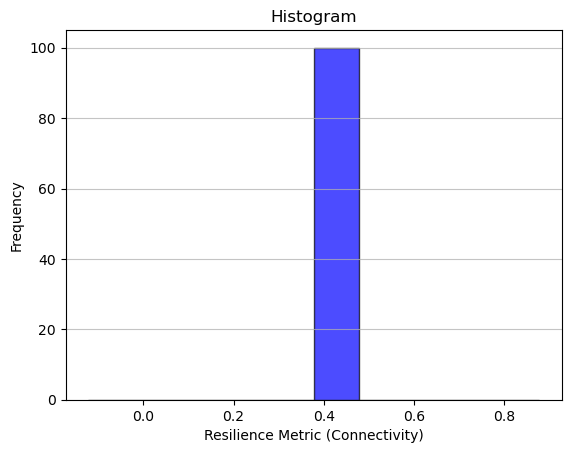

In [63]:
plt.hist(resilience_metric, bins = 10, color = 'blue', edgecolor = 'black', alpha = 0.7)
# Customize the plot
plt.title('Histogram')
plt.xlabel('Resilience Metric (Connectivity)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show plot
plt.show()

## Recovery Models

In [65]:
# buildings_df = building_recovery_model(buildings_df)
# buildings_df = building_power_recovery_model(buildings_df)
# edge_df = road_recovery_model(edge_df)

In [66]:
buildings_df = get_recovery_curve_buildings(buildings_df)
buildings_df = get_recovery_curve_power(buildings_df)
edge_df = get_recovery_curve_roads(edge_df)

/Users/sushreyomisra07/Documents/GitHub/FloodRiskBTP/utility_functions.py:693: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.1840000302409948e-07' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_df.loc[i, 'mean_downtime'] = mean_downtime_days
/Users/sushreyomisra07/Documents/GitHub/FloodRiskBTP/utility_functions.py:694: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.001650212103381498' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_df.loc[i, 'std_downtime'] = stdev_downtime_days
/Users/sushreyomisra07/Documents/GitHub/FloodRiskBTP/utility_functions.py:802: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.001070797033638986' has dtype incompatible w

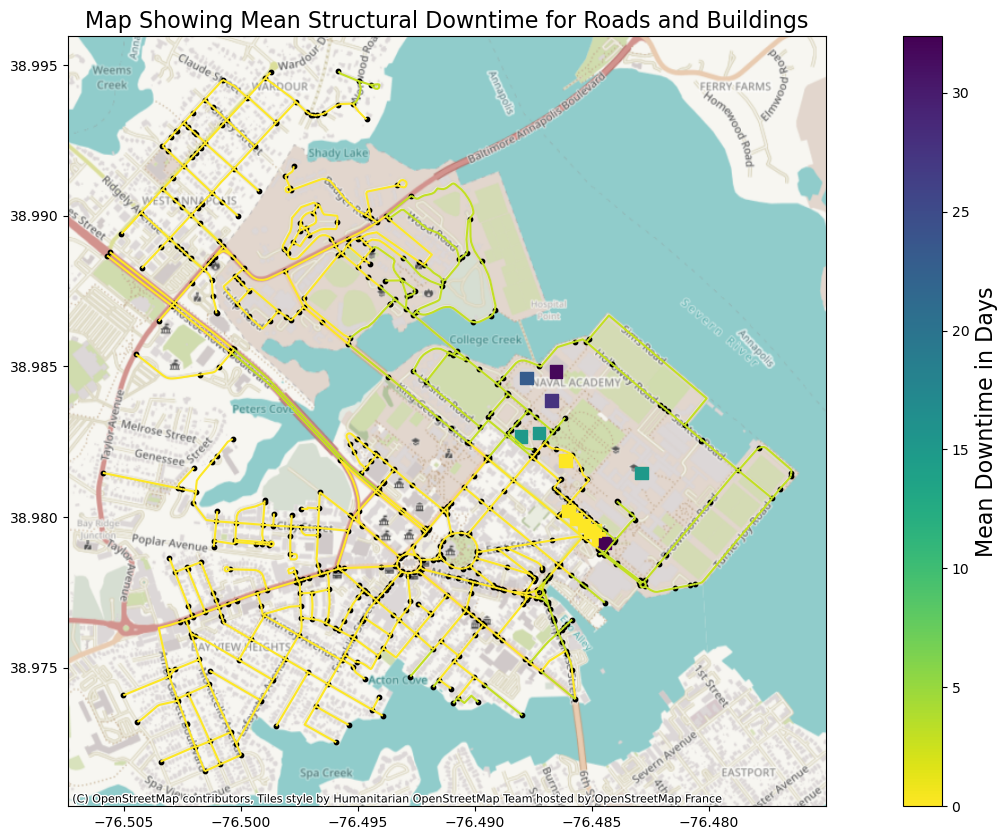

In [67]:
### Plot Transportation Network shapefiles

# Define colormap
cmap = cm.viridis_r
norm = mcolors.Normalize(vmin=0.0, vmax=buildings_df['mean_downtime'].max())

ax = nodes_df.plot(figsize=(20, 10), color = 'k', markersize=10)
edge_plot = edge_df.plot(ax=ax, column='mean_downtime', legend=False, cmap = cmap, norm = norm)
building_plot = buildings_df.plot(ax=ax, column='mean_downtime', marker = 's', markersize=80, legend=False, cmap = cmap, norm = norm)

# Add colorbar manually
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)

# Add label to the colorbar
cbar.set_label("Mean Downtime in Days", fontsize=16)
ax.set_title('Map Showing Mean Structural Downtime for Roads and Buildings', fontsize = 16)

cx.add_basemap(ax, crs=nodes_df.crs)
                

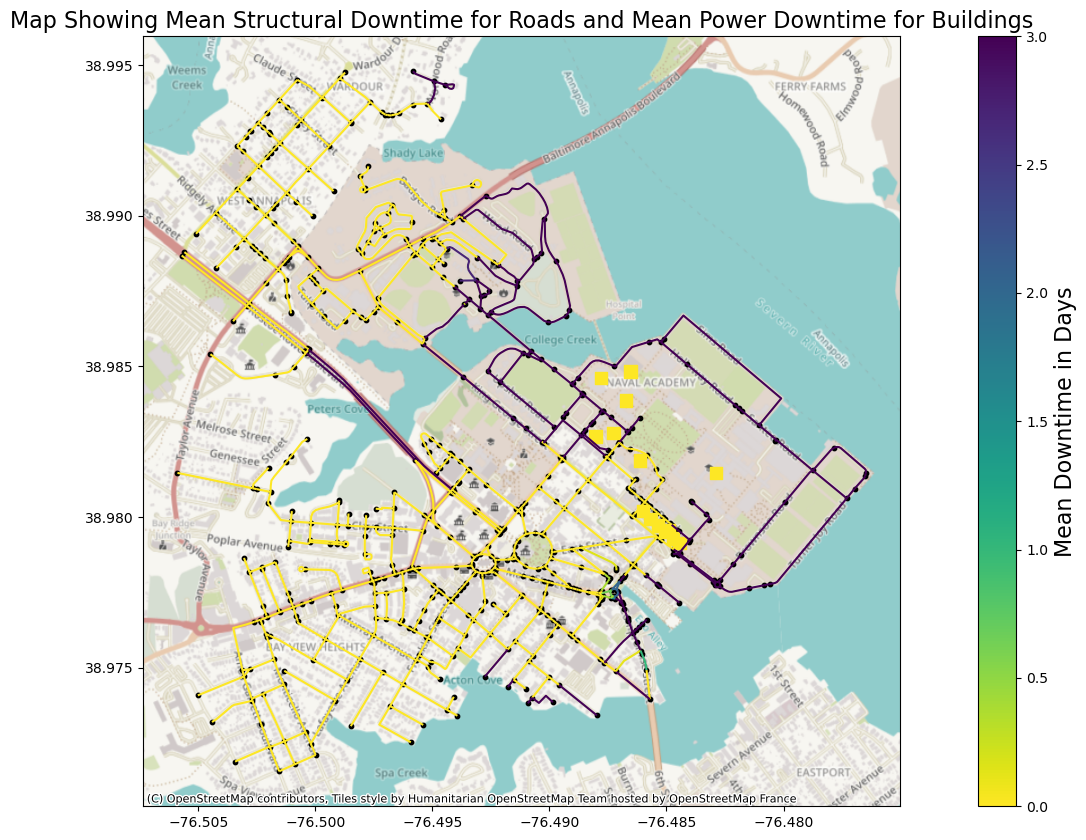

In [68]:
### Plot Transportation Network shapefiles

# Define colormap
cmap = cm.viridis_r
norm = mcolors.Normalize(vmin=0.0, vmax=edge_df['mean_downtime'].max())

ax = nodes_df.plot(figsize=(20, 10), color = 'k', markersize=10)
edge_plot = edge_df.plot(ax=ax, column='mean_downtime', legend=False, cmap = cmap, norm = norm)
building_plot = buildings_df.plot(ax=ax, column='mean_downtime_power', marker = 's', markersize=80, legend=False, cmap = cmap, norm = norm)

# Add colorbar manually
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)

# Add label to the colorbar
cbar.set_label("Mean Downtime in Days", fontsize=16)
ax.set_title('Map Showing Mean Structural Downtime for Roads and Mean Power Downtime for Buildings', fontsize = 16)

cx.add_basemap(ax, crs=nodes_df.crs)

In [135]:
# ax = buildings_df.plot(figsize=(20, 10), color = 'Red', marker = 's', markersize=100)
# # susb_plot = substations_df.plot(ax=ax, color = 'Blue', marker = 'd', markersize = 100)
# cx.add_basemap(ax, crs=buildings_df.crs)

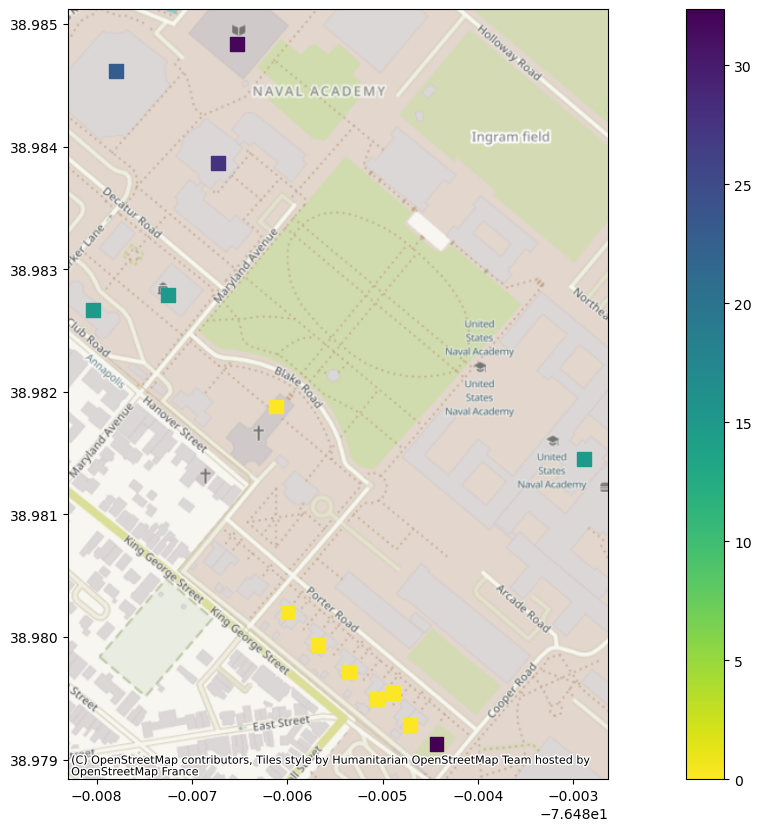

In [151]:
ax = buildings_df.plot(figsize=(20, 10), column='mean_downtime', legend=True, cmap = 'viridis_r', marker = 's', markersize=100)
cx.add_basemap(ax, crs=buildings_df.crs)

## Additional Plots

### Plot MCS Instances

In [73]:
# Pick any simulation number to showcase
simnum = 53

edge_df_mc['sample'] = edge_df_mc.iloc[:, -1].apply(lambda x: x[simnum] if x else None)
edge_df_mc = edge_df_mc[edge_df_mc['sample'] != 1].reset_index(drop = True)
G_temp = create_networkx_graph(nodes_df, edge_df_mc)

# Convert nodes to GeoDataFrame
node_data = {
    "id": list(G_temp.nodes),
    "geometry": [Point(data["geometry"]) for node, data in G_temp.nodes(data=True)],
}
nodes_gdf = gpd.GeoDataFrame(node_data, crs="EPSG:4326")

# Convert edges to GeoDataFrame
edge_data = {
    "source": [u for u, v, data in G_temp.edges(data=True)],
    "target": [v for u, v, data in G_temp.edges(data=True)],
    "weight": [data["length"] for u, v, data in G_temp.edges(data=True)],
    "geometry": [
        LineString([Point(G_temp.nodes[u]["geometry"]), Point(G_temp.nodes[v]["geometry"])])
        for u, v, data in G_temp.edges(data=True)
    ],
}
edges_gdf = gpd.GeoDataFrame(edge_data, crs="EPSG:4326")



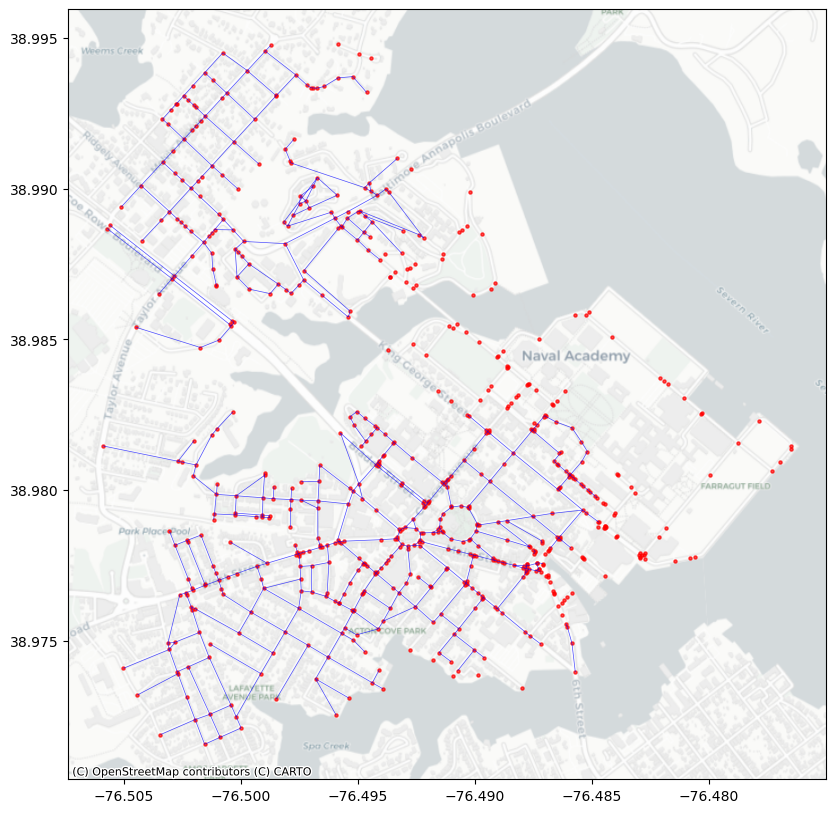

In [74]:
# Plot with basemap
fig, ax = plt.subplots(figsize=(20, 10))
edges_gdf.plot(ax=ax, linewidth=0.5, edgecolor="blue", alpha=0.7)
nodes_gdf.plot(ax=ax, markersize=5, color="red", alpha=0.7)

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=nodes_gdf.crs)

plt.show()

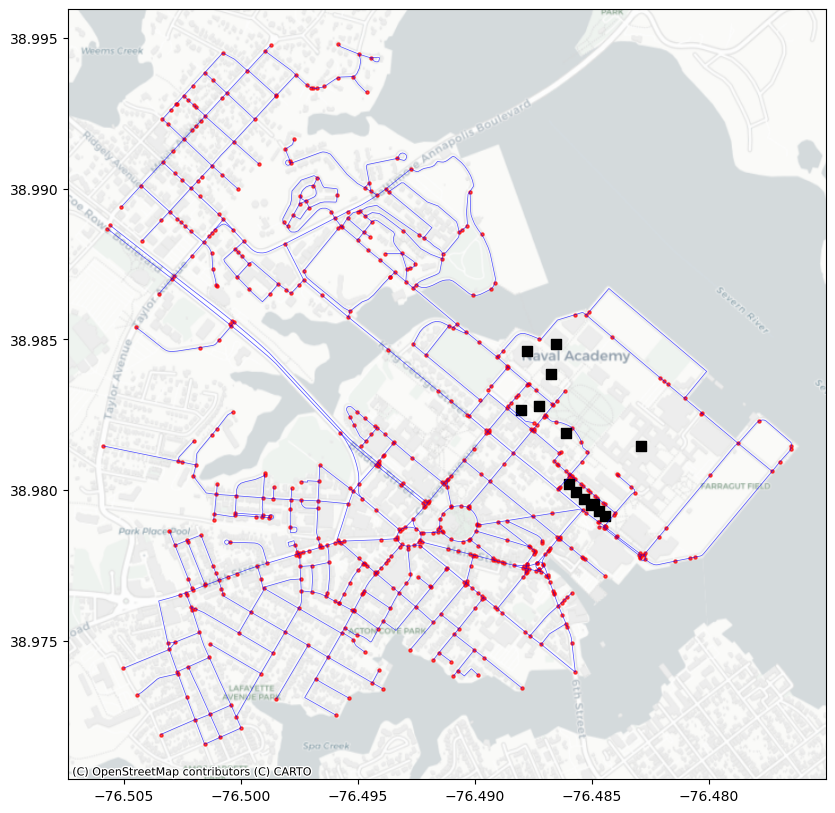

In [75]:
# Plot with basemap
fig, ax = plt.subplots(figsize=(20, 10))
edge_df.plot(ax=ax, linewidth=0.5, edgecolor="blue", alpha=0.7)
nodes_df.plot(ax=ax, markersize=5, color="red", alpha=0.7)
building_plot = buildings_df.plot(ax=ax, marker = 's', markersize=50, color = 'k')

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=nodes_gdf.crs)

plt.show()

### Plot Recovery Curves

#### Aggregated Recovery Curve

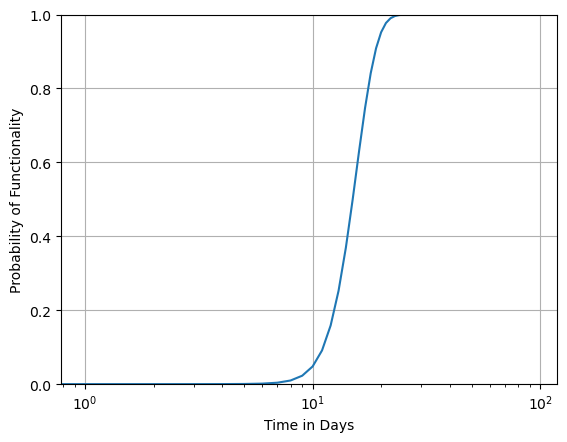

In [78]:
# Showing for a specific building
building_id = 8

time = buildings_df.loc[building_id, 'time']
functionality = buildings_df.loc[building_id, 'recov']

plt.xscale('log')
plt.plot(time, functionality)
plt.grid(True)
plt.ylim(0,1)
plt.xlim(0,np.max(time))
plt.xlabel('Time in Days')
plt.ylabel('Probability of Functionality')
# plt.legend()

plt.show()

In [145]:
# buildings_df.to_csv('building_results_unmitigated.csv')